## The effect of Stellar Temperature on Luminosity of Stars

This code is used to generate the results for the paper. 

### Load libraries

In [60]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import random
import importlib
import generativeAI
importlib.reload(generativeAI)
from generativeAI import *
import kagglehub
from kagglehub import KaggleDatasetAdapter

import gbc.causal
from gbc.causal import CausalIQN, CausalIQNv2, CausalEnsemble



## Estimate the effect of Stellar Temperature on Luminosity of Stars using Generative AI and GRF. 

In [61]:
# Create results directory if it doesn't exist
results_dir = 'results'
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

# Set all seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set R seeds
ro.r('set.seed')(SEED)

def load_and_split_star_data(test_size=0.5, random_state=SEED):
    """
    Load and preprocess stars dataset.

    Covariates are stellar radius plus one-hot encoded colour and category.
    Treatment is a median split of temperature; the outcome is luminosity.
    Supergiants and hypergiants are dropped: in this catalogue they form a
    high-luminosity locus with little temperature contrast.

    Returns
    -------
    X_train, D_train, Y_train, X_test, D_test, Y_test : raw-scale arrays
    Y_train_std, Y_test_std : outcome standardized by the training moments
    y_loc, y_scale : those moments, for returning effects to the raw scale
    T_train, T_test : temperature in K, unstandardized.  It defines the
        treatment so it cannot be a covariate, but the Stefan--Boltzmann
        benchmark needs it as an outcome in the form (T / T_sun)^4.
    R_train, R_test : radius in solar units, unstandardized, for the r^2
        prefactor of the law.  X holds standardized radius and log radius.
    cat_train, cat_test : Star category labels, aligned with the split.
    """
    # Load from local CSV file
    data = pd.read_csv('Stars.csv')
    #data = data.loc[data['Star category'] != 'Hypergiant'].reset_index(drop=True)

    print("Dataset loaded successfully")
    print("Raw data shape:", data.shape)
    print("Available columns:", data.columns.tolist())
    print("After dropping hypergiants:", data.shape)

    # Catalogue is ordered by type; shuffle before the split so that order
    # cannot leak into train/test.  train_test_split shuffles again with
    # the same seed and stratifies on D.
    #data = data.sample(frac=1, random_state=random_state).reset_index(drop=True)

  
    # Covariates: radius and log radius plus stellar classification.
    # Raw radius is dominated by hypergiants after standardizing; log radius
    # keeps within-type size variation visible to the network.
    # Temperature defines the treatment, luminosity is the outcome, and
    # absolute magnitude is an affine function of log luminosity, so none
    # of the three may enter X.
    numerical_features = ['Radius (R/Ro)']
    log_radius = np.log(data['Radius (R/Ro)']).rename('log_Radius (R/Ro)')

    # Star colour is recorded inconsistently ('Blue White', 'Blue-white', ...);
    # normalise case, separators and stray whitespace before encoding.
    colour = (data['Star color'].str.strip().str.lower()
              .str.replace(r'[-_]', ' ', regex=True)
              .str.replace(r'\s+', ' ', regex=True))

    X_numerical = pd.concat(
        [data[numerical_features],
        pd.get_dummies(colour, prefix='color').astype(float),
        pd.get_dummies(data['Star category'], prefix='cat').astype(float)
        ],
        axis=1,
    )
    
    # Create binary treatment based on temperature
    temperature_median = data['Temperature (K)'].median()
    D = (data['Temperature (K)'] > temperature_median).astype(int)
    
    # Outcome: Luminosity
    Y = data['Luminosity (L/Lo)']
    
    T = data['Temperature (K)']
    R = data['Radius (R/Ro)']
    cat = data['Star category']

    print("\nObservations by size (Star category):")
    print(cat.value_counts().sort_index().to_string())

    # Full-sample fit: CATE and the SB check describe this catalogue.
    # Names stay _train/_test so the estimation cell does not change; both
    # aliases are the same 240 stars when test_size is 0 or None.
    if test_size in (0, None):
        X_train = X_test = X_numerical
        D_train = D_test = D
        Y_train = Y_test = Y
        T_train = T_test = T
        R_train = R_test = R
        cat_train = cat_test = cat
    else:
        # Stratify by treatment
        (X_train, X_test, D_train, D_test, Y_train, Y_test,
         T_train, T_test, R_train, R_test,
         cat_train, cat_test) = train_test_split(
            X_numerical, D, Y, T, R, cat,
            test_size=test_size, random_state=random_state, stratify=D
        )
    
    # Optional scale (trees do not need it; the net does).  Always pass a
    # float ndarray to rpy2 / CausalEnsemble — StandardScaler was doing
    # that conversion as a side effect.
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    X_train = np.asarray(X_train, dtype=float)
    X_test = np.asarray(X_test, dtype=float)
    D_train = np.asarray(D_train, dtype=float)
    D_test = np.asarray(D_test, dtype=float)


    # Standardize the outcome using training moments only.  Gradient-based
    # estimators need this because luminosity is of order 1e5; the transform is
    # affine, so effects return to the original scale on multiplication by
    # y_scale alone (the location cancels in a difference).
    Y_train = np.asarray(Y_train, dtype=float)
    Y_test = np.asarray(Y_test, dtype=float)
    y_loc, y_scale = Y_train.mean(), Y_train.std()
    Y_train_std = (Y_train - y_loc) / y_scale
    Y_test_std = (Y_test - y_loc) / y_scale
    
    print("\nDataset Summary:")
    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")
    print("\nObservations by size, train:")
    print(pd.Series(cat_train).value_counts().sort_index().to_string())
    print("\nObservations by size, test:")
    print(pd.Series(cat_test).value_counts().sort_index().to_string())
    print(f"Features ({X_numerical.shape[1]}): {list(X_numerical.columns)}")
    print(f"Training treatment proportion: {D_train.mean():.3f}")
    print(f"Test treatment proportion: {D_test.mean():.3f}")
    print("\nTreatment definition:")
    print(f"Stars with temperature > {temperature_median:.2f}K are treated (hot stars)")
    print(f"Outcome: Luminosity (L/Lo)")
    print(f"Outcome standardization: centred at {y_loc:.4g}, divided by {y_scale:.4g}")
    print(f"Temperature returned unstandardized: "
          f"[{T_train.min():.0f}, {T_train.max():.0f}] K")
    
    return (X_train, D_train, Y_train, X_test, D_test, Y_test,
            Y_train_std, Y_test_std, y_loc, y_scale,
            np.asarray(T_train, dtype=float), np.asarray(T_test, dtype=float),
            np.asarray(R_train, dtype=float), np.asarray(R_test, dtype=float),
            np.asarray(cat_train), np.asarray(cat_test))



Plot the raw densities first:

5776.0


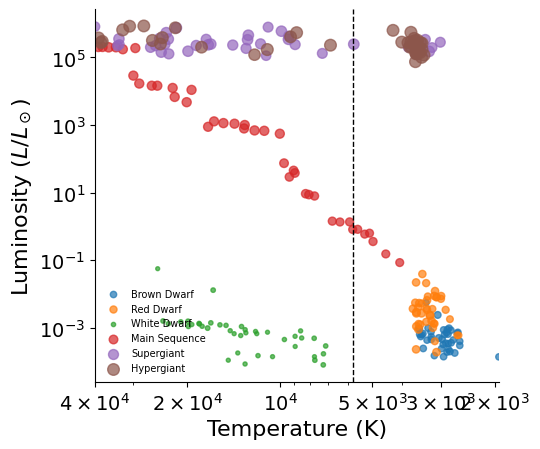

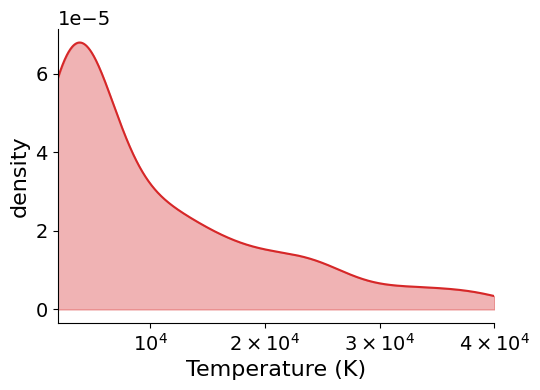

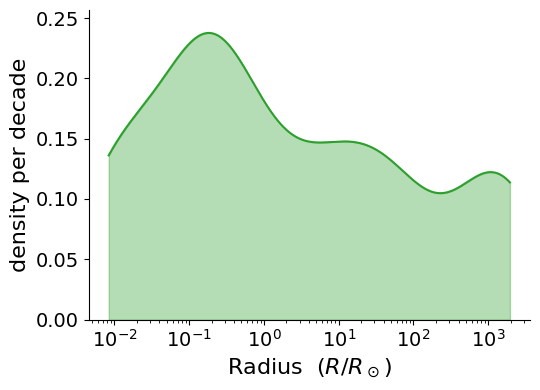

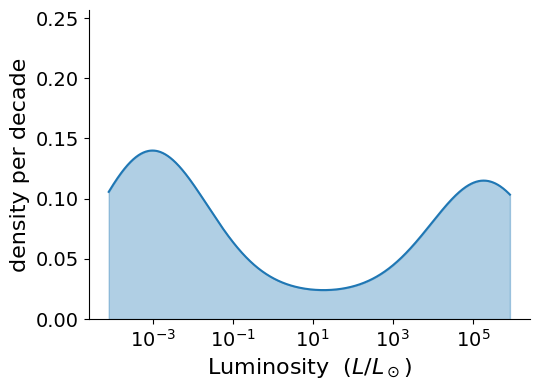

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

stars = pd.read_csv('Stars.csv')
T = stars['Temperature (K)'].to_numpy(float)
L = stars['Luminosity (L/Lo)'].to_numpy(float)
R = stars['Radius (R/Ro)'].to_numpy(float)
t_star = np.median(T)
print(t_star)
t_ticks = [2e3, 3e3, 5e3, 1e4, 2e4, 4e4]
t_ticklabels = [r'$2\times10^{3}$', r'$3\times10^{3}$', r'$5\times10^{3}$',
                r'$10^{4}$', r'$2\times10^{4}$', r'$4\times10^{4}$']
t_lim = (min(T.min(), t_ticks[0]), max(T.max(), t_ticks[-1]))

# (a) Hertzsprung-Russell diagram.
fig, ax = plt.subplots(figsize=(5.5, 4.6))
for cat, colour in zip(stars['Star category'].unique(), plt.cm.tab10.colors):
    m = (stars['Star category'] == cat).to_numpy()
    ax.scatter(T[m], L[m], s=8 + 12 * (np.log10(R[m]) - np.log10(R).min()),
               alpha=0.7, color=colour, label=cat)
ax.axvline(t_star, ls='--', c='k', lw=1)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(*t_lim)
ax.invert_xaxis()
ax.set_xticks(t_ticks)
ax.set_xticklabels(t_ticklabels)
ax.set_xlabel(r'Temperature (K)')
ax.set_ylabel(r'Luminosity ($L/L_\odot$)')
ax.legend(frameon=False, fontsize=7, loc='lower left')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(f'{results_dir}/star_hr_diagram.pdf', bbox_inches='tight')
plt.show()

# (b) Temperature, linear: it spans only a little over one decade.
# Same limits as the HR panel; linear ticks so labels do not pile up at 2e3.
t_ticks_lin = [1e4, 2e4, 3e4, 4e4]
t_ticklabels_lin = [r'$10^{4}$', r'$2\times10^{4}$', r'$3\times10^{4}$',
                    r'$4\times10^{4}$']
fig, ax = plt.subplots(figsize=(5.5, 4.0))
grid = np.linspace(t_lim[0], t_lim[1], 1000)
ax.fill_between(grid, gaussian_kde(T)(grid), color='C3', alpha=0.35)
ax.plot(grid, gaussian_kde(T)(grid), color='C3')
ax.set_xlim(*t_lim)
ax.set_xticks(t_ticks_lin)
ax.set_xticklabels(t_ticklabels_lin)
ax.set_xlabel(r'Temperature (K)')
ax.set_ylabel('density')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(f'{results_dir}/star_density_temperature.pdf', bbox_inches='tight')
plt.show()

# (c), (d) Radius and luminosity in original units on logarithmic axes.
# Both KDEs are densities of log10(value); share the vertical scale.
log_kdes = []
for values, label, stem, colour in [
    (R, r'Radius  ($R/R_\odot$)', 'radius',     'C2'),
    (L, r'Luminosity  ($L/L_\odot$)', 'luminosity', 'C0'),
]:
    lg = np.log10(values)
    grid = np.linspace(lg.min(), lg.max(), 1000)
    density = gaussian_kde(lg)(grid)
    log_kdes.append((10 ** grid, density, label, stem, colour))

ymax = 1.08 * max(density.max() for _, density, _, _, _ in log_kdes)
for x, density, label, stem, colour in log_kdes:
    fig, ax = plt.subplots(figsize=(5.5, 4.0))
    ax.fill_between(x, density, color=colour, alpha=0.35)
    ax.plot(x, density, color=colour)
    ax.set_xscale('log')
    ax.set_ylim(0, ymax)
    ax.set_xlabel(label)
    ax.set_ylabel('density per decade')
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    fig.savefig(f'{results_dir}/star_density_{stem}.pdf', bbox_inches='tight')
    plt.show()

In [56]:
# Import R's GRF package
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import numpy2ri
base = importr('base')
grf = importr('grf')
# Load and split data
(X_train, D_train, Y_train, X_test, D_test, Y_test,
            Y_train_std, Y_test_std, y_loc, y_scale,
            T_train, T_test,
            R_train, R_test,
            cat_train, cat_test) = load_and_split_star_data()
            
# Convert to R and run GRF.  numpy2ri needs ndarrays, not a DataFrame;
# scaling is irrelevant for the forest.
X_tr = np.asarray(X_train, dtype=float)
X_te = np.asarray(X_test, dtype=float)
D_tr = np.asarray(D_train, dtype=float)
D_te = np.asarray(D_test, dtype=float)
Y_tr = np.asarray(Y_train, dtype=float)
Y_te = np.asarray(Y_test, dtype=float)

with localconverter(ro.default_converter + numpy2ri.converter):
    X_train_r = ro.r.matrix(X_tr, nrow=X_tr.shape[0], ncol=X_tr.shape[1])
    D_train_r = ro.FloatVector(D_tr)
    Y_train_r = ro.FloatVector(Y_tr)
    X_test_r = ro.r.matrix(X_te, nrow=X_te.shape[0], ncol=X_te.shape[1])
    D_test_r = ro.FloatVector(D_te)
    Y_test_r = ro.FloatVector(Y_te)

    print("\nTraining GRF model...")
    cf = grf.causal_forest(X_train_r, Y_train_r, D_train_r, seed=SEED)
    pred_grf = grf.predict_causal_forest(cf, X_test_r)
    tau_grf_test = np.array(pred_grf.rx2('predictions') if hasattr(pred_grf, 'rx2') else pred_grf['predictions'])

    ens = CausalEnsemble(model_cls=CausalIQN,
                        model_kwargs={"xdim": X_tr.shape[1],  "nh": 32},
                        n_models=3)
    ens.fit(X_tr, Y_tr, D_tr,
            epochs=3000, lr=0.006, weight_decay=0, verbose=False)
    cate_out = ens.estimate_cate(X_te)
    tau_gen_test = cate_out['cate']


    # predict the outcome  (factual E[Y | X, D] at observed treatment)
    x_t = torch.tensor(np.asarray(X_test, dtype=float), dtype=torch.float32, device=ens.device)
    z_t = torch.tensor(np.asarray(D_test, dtype=float), dtype=torch.float32, device=ens.device)
    q_grid = (np.arange(20) + 0.5) / 20

    L_hat = np.zeros(len(X_test))
    for model in ens.models:
        model.eval()
        with torch.no_grad():
            for q in q_grid:
                f, _, _, _ = model(x_t, z_t, float(q))
                L_hat += f[:, 1].cpu().numpy()
    L_hat /= ens.n_models * len(q_grid)

print("\nTest Set Results:")
print("GRF:")
print(f"Average Treatment Effect: {np.mean(tau_grf_test):.2f}")
print(f"Standard Deviation: {np.std(tau_grf_test):.2f}")

print("\nGenerativeTE (estimate_cate):")
print(f"Average Treatment Effect: {cate_out['ate']:.2f}")
print(f"ATE SE: {cate_out['ate_se']:.2f}")
print(f"ATE 95% CI: ({cate_out['ate_ci'][0]:.2f}, {cate_out['ate_ci'][1]:.2f})")
print(f"CATE SD: {np.std(tau_gen_test):.2f}")


Dataset loaded successfully
Raw data shape: (240, 8)
Available columns: ['Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Absolute magnitude (Mv)', 'Star type', 'Star category', 'Star color', 'Spectral Class']
After dropping hypergiants: (240, 8)

Observations by size (Star category):
Star category
Brown Dwarf      40
Hypergiant       40
Main Sequence    40
Red Dwarf        40
Supergiant       40
White Dwarf      40

Dataset Summary:
Training samples: 120
Test samples: 120

Observations by size, train:
Star category
Brown Dwarf      17
Hypergiant       29
Main Sequence    19
Red Dwarf        18
Supergiant       17
White Dwarf      20

Observations by size, test:
Star category
Brown Dwarf      23
Hypergiant       11
Main Sequence    21
Red Dwarf        22
Supergiant       23
White Dwarf      20
Features (19): ['Radius (R/Ro)', 'color_blue', 'color_blue white', 'color_orange', 'color_orange red', 'color_pale yellow orange', 'color_red', 'color_white', 'color_white yellow', 'colo

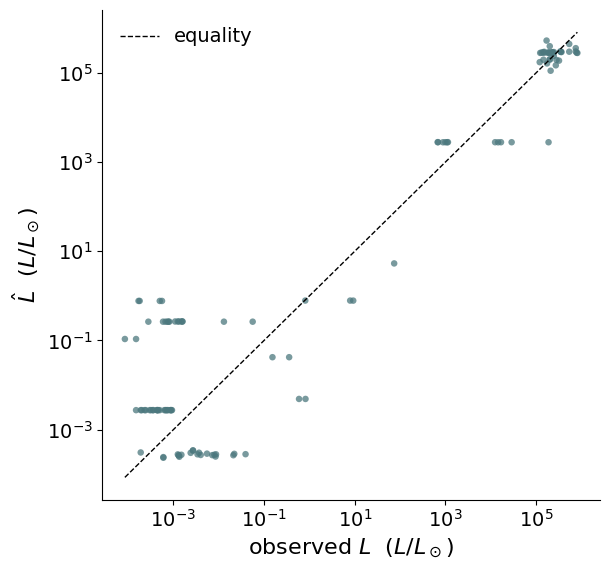

In [57]:
import pandas as pd
import matplotlib.pyplot as plt


y_te = np.asarray(Y_test, dtype=float)
pos = (L_hat > 0) & (y_te > 0)

plt.rcParams.update({
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'axes.labelsize': 16, 'xtick.labelsize': 14,
    'ytick.labelsize': 14, 'legend.fontsize': 14,
})

fig, ax = plt.subplots(figsize=(6.2, 5.8))
ax.scatter(y_te[pos], L_hat[pos], s=22, alpha=0.75,
           color='#4C787E', edgecolor='none')
lim = [min(y_te[pos].min(), L_hat[pos].min()),
       max(y_te[pos].max(), L_hat[pos].max())]
ax.plot(lim, lim, ls='--', c='k', lw=1, label='equality')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'observed $L$  ($L/L_\odot$)')
ax.set_ylabel(r'$\hat L$  ($L/L_\odot$)')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(results_dir, 'Lhat_vs_Ytest.pdf'),
            bbox_inches='tight')
plt.show()


## Density plot for the effect of Stellar Temperature on Luminosity of Stars (Generative AI)

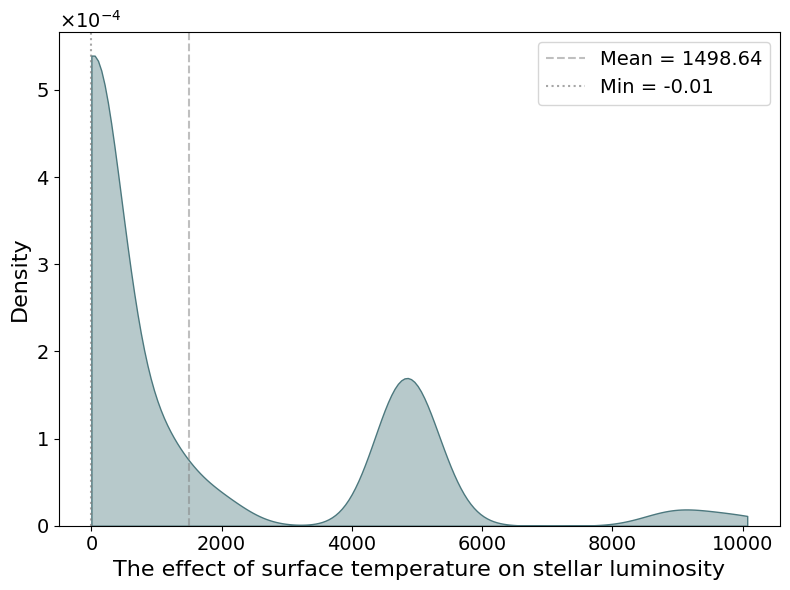

GenTE (test): n = 120, negative = 0 (0.0%)
  min = -0.01388, median = 0.2062, max = 1.007e+04
-0.01388251


In [58]:


# Set style for better PDF output
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
# Increase only axis-related font sizes
plt.rcParams['axes.labelsize'] = 16  # Increased axis label size
plt.rcParams['xtick.labelsize'] = 14  # Increased tick label size
plt.rcParams['ytick.labelsize'] = 14  # Increased tick label size
plt.rcParams['legend.fontsize'] = 14  # Increased legend size

# Calculate mean of treatment effects
mean_effect = np.mean(tau_gen_test)
min_effect = np.min(tau_gen_test)



# Create density plot
plt.figure(figsize=(8, 6))
sns.kdeplot(data=tau_gen_test, color='#4C787E', fill=True, alpha=0.4,
            cut=0, bw_adjust=0.5, label='')

# Format y-axis to use scientific notation
plt.gca().yaxis.set_major_formatter(plt.ScalarFormatter(useMathText=True))
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))


plt.xlabel('The effect of surface temperature on stellar luminosity')
plt.ylabel('Density')
plt.title('')
plt.axvline(x=mean_effect, color='gray', linestyle='--', alpha=0.5, label=f'Mean = {mean_effect:.2f}')
plt.axvline(x=min_effect, color='gray', linestyle=':', alpha=0.7,
            label=f'Min = {min_effect:.2f}')
plt.legend()
plt.tight_layout()

# Save plots
plt.savefig(os.path.join(results_dir, 'treatment_effects_density.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(results_dir, 'treatment_effects_density.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()



def print_negative_share(theta, name='theta_hat'):
    theta = np.asarray(theta, float).ravel()
    neg = theta < -0.1
    print(f"{name}: n = {theta.size}, negative = {neg.sum()} "
          f"({100.0 * neg.mean():.1f}%)")
    print(f"  min = {theta.min():.4g}, median = {np.median(theta):.4g}, "
          f"max = {theta.max():.4g}")


print_negative_share(tau_gen_test, 'GenTE (test)')


print(min(tau_gen_test))

## Density plot for the effect of Stellar Temperature on Luminosity of Stars (GRF)

GRF (test): n = 120, negative = 120 (100.0%)
  min = -1.206e+05, median = -6.487e+04, max = -6.412e+04


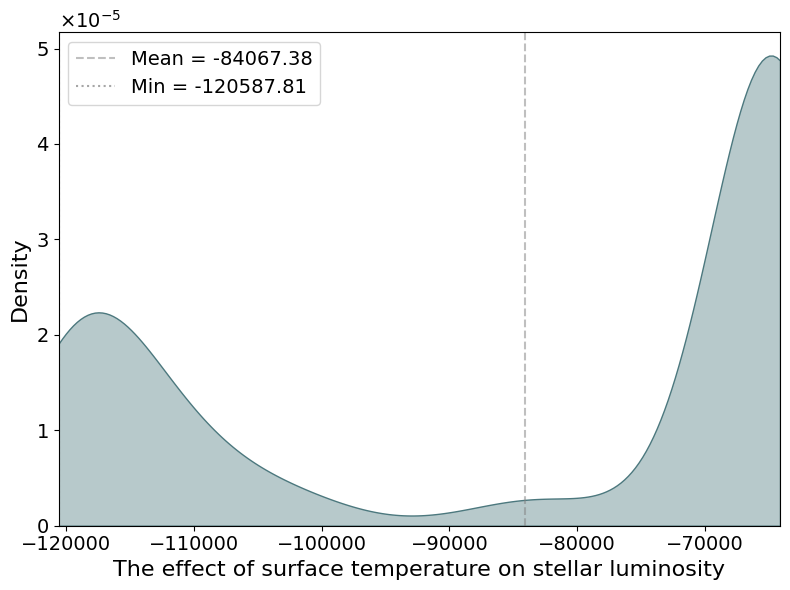

In [42]:
## Such a plot for GRF
# Set style for better PDF output
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14

print_negative_share(tau_grf_test, 'GRF (test)')

mean_effect_grf = np.mean(tau_grf_test)
min_effect_grf  = np.min(tau_grf_test)
max_effect_grf  = np.max(tau_grf_test)

plt.figure(figsize=(8, 6))
sns.kdeplot(data=tau_grf_test,
            color='#4C787E',
            fill=True,
            alpha=0.4,
            cut=0,
            bw_adjust=0.5,
            label='')

# scientific notation on the y-axis as a power of ten, not e-notation
plt.gca().yaxis.set_major_formatter(plt.ScalarFormatter(useMathText=True))
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.xlim(min_effect_grf, max_effect_grf)

plt.xlabel('The effect of surface temperature on stellar luminosity')
plt.ylabel('Density')
plt.title('')
plt.axvline(x=mean_effect_grf, color='gray', linestyle='--', alpha=0.5,
            label=f'Mean = {mean_effect_grf:.2f}')
plt.axvline(x=min_effect_grf, color='gray', linestyle=':', alpha=0.7,
            label=f'Min = {min_effect_grf:.2f}')
plt.legend()
plt.tight_layout()

plt.savefig(os.path.join(results_dir, 'treatment_effects_density_grf.pdf'),
            dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(results_dir, 'treatment_effects_density_grf.png'),
            dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Test

Regress predicted log(L_hat) on log(R/R_0) Fourth power of log(T/T_0). The slopes must be 2 and 4. 

In [43]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

T_SUN = 5772.0
R = np.asarray(R_test, dtype=float)
T = np.asarray(T_test, dtype=float)
Lh = np.asarray(L_hat, dtype=float)

ok = (Lh > 0) & (R > 0) & (T > 0)
df = pd.DataFrame({
    'log_L': np.log(Lh[ok]),
    'log_R': np.log(R[ok]),                 # law: 2
    'log_T': np.log(T[ok] / T_SUN),         # law: 4
})
res = sm.OLS.from_formula('log_L ~ log_R + log_T', data=df).fit()
print(res.summary())
#print('Joint (2, 4):\n', res.f_test('log_R = 2, log_T = 4'))
print('Joint (0, 2, 4):\n', res.f_test('Intercept = 0, log_R = 2, log_T = 4'))


                            OLS Regression Results                            
Dep. Variable:                  log_L   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     381.2
Date:                Sun, 06 Sep 2026   Prob (F-statistic):           5.67e-52
Time:                        20:05:34   Log-Likelihood:                -304.32
No. Observations:                 120   AIC:                             614.6
Df Residuals:                     117   BIC:                             623.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0609      0.293      0.208      0.8

In [44]:

print(res.t_test('log_R = 2'))
print(res.t_test('log_T = 4'))

                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0             1.6374      0.082     -4.447      0.000       1.476       1.799
                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0             4.6363      0.335      1.899      0.060       3.973       5.300


## Test using the original luminosity

In [45]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

T_SUN = 5772.0
R = np.asarray(R_test, dtype=float)
T = np.asarray(T_test, dtype=float)
Lh = np.asarray(Y_test, dtype=float)

ok = (Lh > 0) & (R > 0) & (T > 0)
df = pd.DataFrame({
    'log_L': np.log(Lh[ok]),
    'log_R': np.log(R[ok]),                 # law: 2
    'log_T': np.log(T[ok] / T_SUN),         # law: 4
})
res = sm.OLS.from_formula('log_L ~ log_R + log_T', data=df).fit()
print(res.summary())
print(res.f_test('log_R = 2, log_T = 4'))


                            OLS Regression Results                            
Dep. Variable:                  log_L   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     1076.
Date:                Sun, 06 Sep 2026   Prob (F-statistic):           4.69e-76
Time:                        20:05:34   Log-Likelihood:                -254.86
No. Observations:                 120   AIC:                             515.7
Df Residuals:                     117   BIC:                             524.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.4520      0.194     -2.330      0.0

## Studying The Effect Heterogeneity

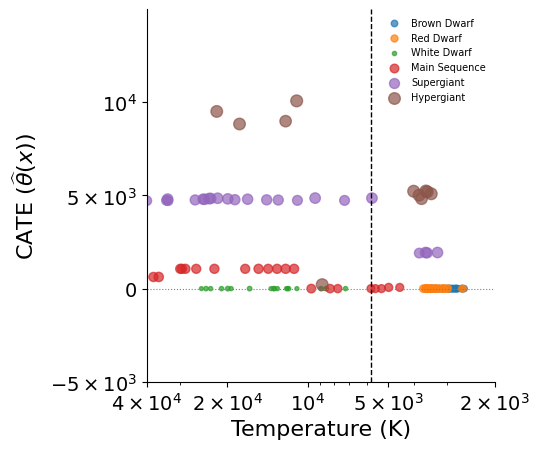

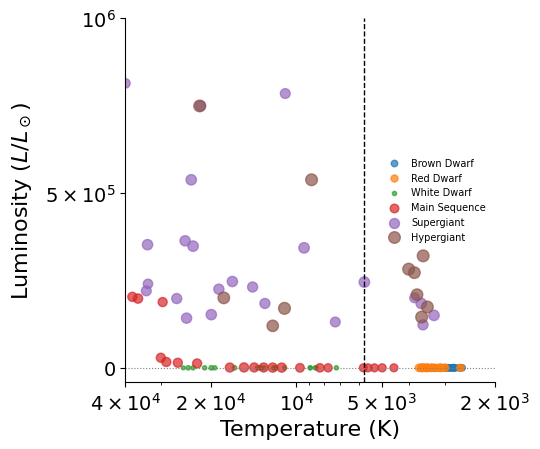

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

T_hr = np.asarray(T_test, dtype=float)
R_hr = np.asarray(R_test, dtype=float)
L_hr = np.asarray(Y_test, dtype=float)
tau = np.asarray(tau_gen_test, dtype=float)
cat_hr = np.asarray(cat_test)
# Full-sample median that defines D, not the test-set median.
t_cut = t_star if 't_star' in dir() else np.median(T_hr)
r_size = 8 + 12 * (np.log10(R_hr) - np.log10(R_hr).min())

t_ticks = [2e3, 5e3, 1e4, 2e4, 4e4]
t_ticklabels = [r'$2\times10^{3}$', r'$5\times10^{3}$',
                r'$10^{4}$', r'$2\times10^{4}$', r'$4\times10^{4}$']
t_lim = (min(T_hr.min(), t_ticks[0]), max(T_hr.max(), t_ticks[-1]))

cat_order = [
    'Brown Dwarf', 'Red Dwarf', 'White Dwarf',
    'Main Sequence', 'Supergiant', 'Hypergiant',
]
colours = plt.cm.tab10.colors


def _style_temperature_axis(ax):
    ax.set_xscale('log')
    ax.set_xlim(*t_lim)
    ax.invert_xaxis()
    ax.set_xticks(t_ticks)
    ax.set_xticklabels(t_ticklabels)
    ax.set_xlabel(r'Temperature (K)')
    ax.axvline(t_cut, ls='--', c='k', lw=1)
    ax.spines[['top', 'right']].set_visible(False)


# (a) Same HR geometry, CATE on the vertical axis.
fig, ax = plt.subplots(figsize=(5.5, 4.6))
for cat, colour in zip(cat_order, colours):
    m = cat_hr == cat
    if not np.any(m):
        continue
    ax.scatter(T_hr[m], tau[m], s=r_size[m], alpha=0.7, color=colour, label=cat)
_style_temperature_axis(ax)
tau_lo = min(float(np.min(tau)), 0.0)
if tau_lo >= 0:
    tau_lo = -0.08 * max(float(np.max(tau)), 1.0)
else:
    tau_lo = 1.15 * tau_lo
tau_hi = max(np.ceil(float(np.max(tau)) / 5e3) * 5e3, 1e4)
ax.set_yscale('linear')
ax.set_ylim(tau_lo, tau_hi)
ax.set_yticks([-5e3, 0, 5e3, 1e4])
ax.set_yticklabels([r'$-5\times10^{3}$', r'$0$', r'$5\times10^{3}$', r'$10^{4}$'])
ax.axhline(0, ls=':', c='0.5', lw=0.8)
ax.set_ylabel(r'CATE ($\widehat{\theta}(x)$)', labelpad=8)
ax.legend(frameon=False, fontsize=7, loc='upper right')
fig.tight_layout()
fig.savefig(os.path.join(results_dir, 'star_hr_cate.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(results_dir, 'star_hr_cate.png'), dpi=300, bbox_inches='tight')
plt.show()

# (b) Observed HR on the test stars.
fig, ax = plt.subplots(figsize=(5.5, 4.6))
for cat, colour in zip(cat_order, colours):
    m = cat_hr == cat
    if not np.any(m):
        continue
    ax.scatter(T_hr[m], L_hr[m], s=r_size[m], alpha=0.7, color=colour, label=cat)
_style_temperature_axis(ax)
L_hi = max(np.ceil(float(np.max(L_hr)) / 2e5) * 2e5, 1e6)
L_lo = -0.04 * L_hi
ax.set_yscale('linear')
ax.set_ylim(L_lo, L_hi)
ax.set_yticks([0, 5e5, 1e6])
ax.set_yticklabels([r'$0$', r'$5\times10^{5}$', r'$10^{6}$'])
ax.axhline(0, ls=':', c='0.5', lw=0.8)
ax.set_ylabel(r'Luminosity ($L/L_\odot$)', labelpad=8)
ax.legend(frameon=False, fontsize=7, loc='center right')
fig.tight_layout()
fig.savefig(os.path.join(results_dir, 'star_hr_cate_on_hr.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(results_dir, 'star_hr_cate_on_hr.png'), dpi=300, bbox_inches='tight')
plt.show()



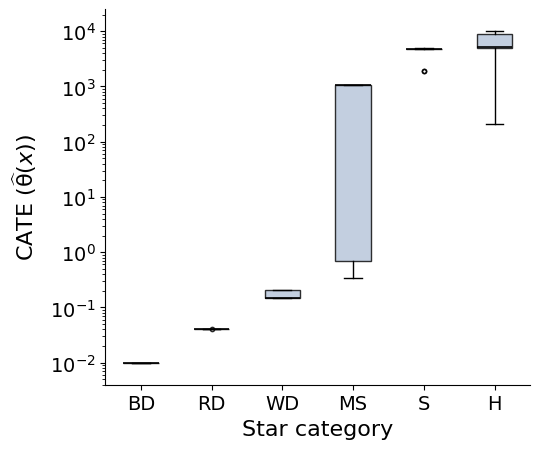

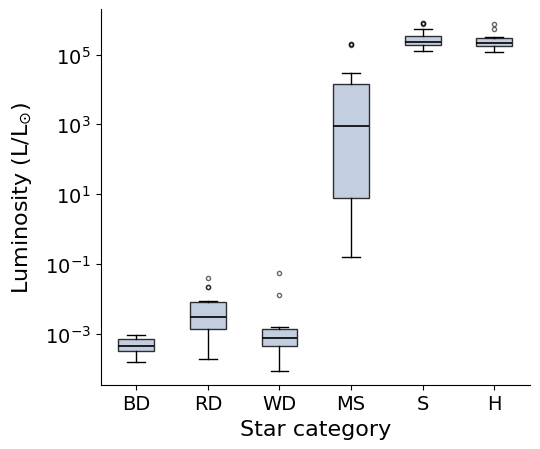

Mean CATE by Star category:
Brown Dwarf        -0.01
Red Dwarf           0.04
White Dwarf         0.17
Main Sequence     621.98
Supergiant       4286.81
Hypergiant       6197.72


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

T_hr = np.asarray(T_test, dtype=float)
R_hr = np.asarray(R_test, dtype=float)
L_hr = np.asarray(Y_test, dtype=float)
tau = np.asarray(tau_gen_test, dtype=float)
cat_hr = np.asarray(cat_test)
# Full-sample median that defines D, not the test-set median.
t_cut = t_star if 't_star' in dir() else np.median(T_hr)
r_size = 8 + 12 * (np.log10(R_hr) - np.log10(R_hr).min())

t_ticks = [2e3, 5e3, 1e4, 2e4, 4e4]
t_ticklabels = [r'$2\times10^{3}$', r'$5\times10^{3}$',
                r'$10^{4}$', r'$2\times10^{4}$', r'$4\times10^{4}$']
t_lim = (min(T_hr.min(), t_ticks[0]), max(T_hr.max(), t_ticks[-1]))

cat_order = [
    'Brown Dwarf', 'Red Dwarf', 'White Dwarf',
    'Main Sequence', 'Supergiant', 'Hypergiant',
]
#colours = plt.cm.tab10.colors
colours = ['#B4C4D9'] * len(cat_order)


def _style_temperature_axis(ax):
    ax.set_xscale('log')
    ax.set_xlim(*t_lim)
    ax.invert_xaxis()
    ax.set_xticks(t_ticks)
    ax.set_xticklabels(t_ticklabels)
    ax.set_xlabel(r'Temperature (K)')
    ax.axvline(t_cut, ls='--', c='k', lw=1)
    ax.spines[['top', 'right']].set_visible(False)



cat_abbrev = {
    'Brown Dwarf': 'BD', 'Red Dwarf': 'RD', 'White Dwarf': 'WD',
    'Main Sequence': 'MS', 'Supergiant': 'S', 'Hypergiant': 'H',
}


def _category_boxplot(values, ylabel, stem):
    data, labels, face = [], [], []
    for cat, colour in zip(cat_order, colours):
        m = cat_hr == cat
        x = values[m] if np.any(m) else np.array([])
        x = x[np.isfinite(x)]
        # Log scale needs strictly positive values; keep BD (and any
        # non-positive CATE) on the axis at a small floor.
        eps = 1e-2
        if x.size == 0:
            x = np.full(1, eps)
        else:
            x = np.where(x > 0, x, eps)
        data.append(x)
        labels.append(cat_abbrev[cat])
        face.append(colour)
    fig, ax = plt.subplots(figsize=(5.5, 4.6))
    bp = ax.boxplot(
        data, tick_labels=labels, patch_artist=True,
        medianprops=dict(color='k', lw=1.2),
        whiskerprops=dict(color='k'),
        capprops=dict(color='k'),
        flierprops=dict(marker='o', ms=3, alpha=0.6),
    )
    for patch, colour in zip(bp['boxes'], face):
        patch.set_facecolor(colour)
        patch.set_alpha(0.8)
        patch.set_edgecolor('k')
    ymin = min(float(np.min(d)) for d in data)
    ymax = max(float(np.max(d)) for d in data)
    ax.set_yscale('log')
    ax.set_ylim(ymin * 0.4, ymax * 2.5)
    ax.set_ylabel(ylabel, labelpad=8)
    ax.set_xlabel('Star category')
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    fig.savefig(os.path.join(results_dir, f'{stem}.pdf'), bbox_inches='tight')
    fig.savefig(os.path.join(results_dir, f'{stem}.png'), dpi=300, bbox_inches='tight')
    plt.show()


_category_boxplot(tau, r'CATE ($\mathrm{\widehat{\theta}}(x)$)', 'star_cate_box')
_category_boxplot(L_hr, r'Luminosity ($\mathrm{L}/\mathrm{L}_{\odot}$)',
                  'star_luminosity_box')

print('Mean CATE by Star category:')
print(pd.Series(tau).groupby(cat_hr).mean().reindex(cat_order).dropna().round(2).to_string())


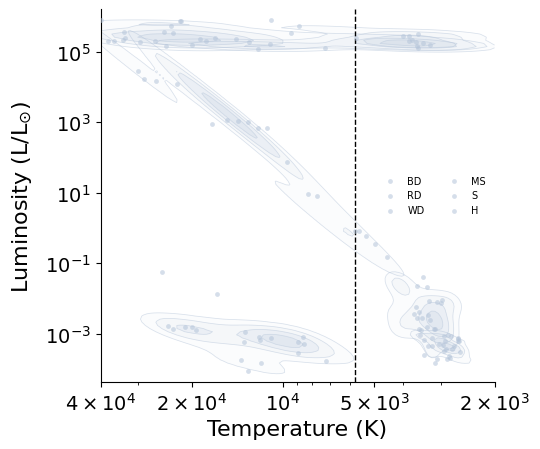

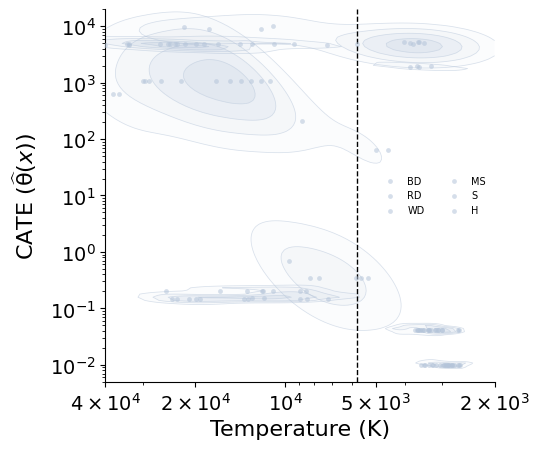

In [48]:
from matplotlib.colors import LinearSegmentedColormap, to_rgb
from scipy.stats import gaussian_kde

# Two plots, all classes on the same axes: soft filled contours per type.
# Small jitter + wider bandwidth avoids singular KDE when a class is tight.

#cat_abbrev = {
#    'Brown Dwarf': 'Brown Dwarf', 'Red Dwarf': 'Red Dwarf', 'White Dwarf': 'White Dwarf',
#    'Main Sequence': 'Main Sequence', 'Supergiant': 'Supergiant', 'Hypergiant': 'Hypergiant',
#}


cat_abbrev = {
    'Brown Dwarf': 'BD', 'Red Dwarf': 'RD', 'White Dwarf': 'WD',
    'Main Sequence': 'MS', 'Supergiant': 'S', 'Hypergiant': 'H',
}


def _soft_cmap(colour):
    r, g, b = to_rgb(colour)
    return LinearSegmentedColormap.from_list(
        'soft', [(r, g, b, 0.0), (r, g, b, 0.16), (r, g, b, 0.42)],
    )


def _class_kde(xi, yi, grid, shape, rng):
    if xi.size < 3:
        return None
    pts = np.vstack([xi, yi]) + rng.normal(0, 0.05, size=(2, xi.size))
    try:
        kde = gaussian_kde(pts, bw_method=0.5)
    except np.linalg.LinAlgError:
        return None
    Z = np.clip(kde(grid).reshape(shape), 0, None)
    zmax = Z.max()
    return None if zmax <= 0 else Z / zmax


def _overlay_heatmaps(x, y, ylabel, stem, y_floor=None, legend_loc='center right'):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if y_floor is not None:
        y = np.where(np.isfinite(y) & (y > 0), y, y_floor)
    y_pos = y[np.isfinite(y) & (y > 0)]
    y_lo, y_hi = np.log10(y_pos.min() * 0.5), np.log10(y_pos.max() * 2)
    xg = np.linspace(np.log10(t_lim[0]), np.log10(t_lim[1]), 120)
    yg = np.linspace(y_lo, y_hi, 120)
    Xg, Yg = np.meshgrid(xg, yg)
    grid = np.vstack([Xg.ravel(), Yg.ravel()])
    rng = np.random.default_rng(0)
    levels = [0.28, 0.48, 0.68, 0.88, 1.0]

    fig, ax = plt.subplots(figsize=(5.5, 4.6))
    for cat, colour in zip(cat_order, colours):
        m = (cat_hr == cat)
        xi = np.log10(x[m])
        yi = np.log10(np.where(y[m] > 0, y[m], y_pos.min() * 0.5))
        ok = np.isfinite(xi) & np.isfinite(yi)
        xi, yi = xi[ok], yi[ok]
        Z = _class_kde(xi, yi, grid, Xg.shape, rng)
        if Z is not None:
            ax.contourf(10 ** xg, 10 ** yg, Z, levels=levels,
                        cmap=_soft_cmap(colour), antialiased=True)
            ax.contour(10 ** xg, 10 ** yg, Z, levels=levels,
                       colors=[colour], linewidths=0.55, alpha=0.5)
        ax.scatter(10 ** xi, 10 ** yi, s=12, color=colour, alpha=0.55,
                   linewidths=0, label=cat_abbrev[cat], zorder=3)
    _style_temperature_axis(ax)
    ax.set_yscale('log')
    ax.set_ylim(10 ** y_lo, 10 ** y_hi)
    ax.set_ylabel(ylabel, labelpad=8)
    ax.legend(frameon=False, fontsize=7, loc=legend_loc, ncol=2)
    fig.tight_layout()
    fig.savefig(os.path.join(results_dir, f'{stem}.pdf'), bbox_inches='tight')
    fig.savefig(os.path.join(results_dir, f'{stem}.png'), dpi=300, bbox_inches='tight')
    plt.show()


_overlay_heatmaps(T_hr, L_hr, r'Luminosity ($\mathrm{L}/\mathrm{L}_{\odot}$)',
                  'star_heatmap_TL', legend_loc='center right')
_overlay_heatmaps(T_hr, tau, r'CATE ($\mathrm{\widehat{\theta}}(x)$)',
                  'star_heatmap_Ttau', y_floor=1e-2, legend_loc='center right')


# Rerun GRF on a Log Scale (Log Luminosity)

In [49]:
# Create results directory if it doesn't exist
results_dir = 'results'
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

# Set all seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set R seeds
ro.r('set.seed')(SEED)

def load_and_split_star_data_log(test_size=0.5, random_state=SEED):
    """
    Load and preprocess stars dataset.

    Covariates are stellar radius plus one-hot encoded colour and category.
    Treatment is a median split of temperature; the outcome is luminosity.
    Supergiants and hypergiants are dropped: in this catalogue they form a
    high-luminosity locus with little temperature contrast.

    Returns
    -------
    X_train, D_train, Y_train, X_test, D_test, Y_test : raw-scale arrays
    Y_train_std, Y_test_std : outcome standardized by the training moments
    y_loc, y_scale : those moments, for returning effects to the raw scale
    T_train, T_test : temperature in K, unstandardized.  It defines the
        treatment so it cannot be a covariate, but the Stefan--Boltzmann
        benchmark needs it as an outcome in the form (T / T_sun)^4.
    R_train, R_test : radius in solar units, unstandardized, for the r^2
        prefactor of the law.  X holds standardized radius and log radius.
    cat_train, cat_test : Star category labels, aligned with the split.
    """
    # Load from local CSV file
    data = pd.read_csv('Stars.csv')
    #data = data.loc[data['Star category'] != 'Hypergiant'].reset_index(drop=True)

    print("Dataset loaded successfully")
    print("Raw data shape:", data.shape)
    print("Available columns:", data.columns.tolist())
    print("After dropping hypergiants:", data.shape)

    # Catalogue is ordered by type; shuffle before the split so that order
    # cannot leak into train/test.  train_test_split shuffles again with
    # the same seed and stratifies on D.
    #data = data.sample(frac=1, random_state=random_state).reset_index(drop=True)

  
    # Covariates: radius and log radius plus stellar classification.
    # Raw radius is dominated by hypergiants after standardizing; log radius
    # keeps within-type size variation visible to the network.
    # Temperature defines the treatment, luminosity is the outcome, and
    # absolute magnitude is an affine function of log luminosity, so none
    # of the three may enter X.
    numerical_features = ['Radius (R/Ro)']
    log_radius = np.log(data['Radius (R/Ro)']).rename('log_Radius (R/Ro)')

    # Star colour is recorded inconsistently ('Blue White', 'Blue-white', ...);
    # normalise case, separators and stray whitespace before encoding.
    colour = (data['Star color'].str.strip().str.lower()
              .str.replace(r'[-_]', ' ', regex=True)
              .str.replace(r'\s+', ' ', regex=True))

    X_numerical = pd.concat(
        [data[numerical_features],
        pd.get_dummies(colour, prefix='color').astype(float),
        pd.get_dummies(data['Star category'], prefix='cat').astype(float)
        ],
        axis=1,
    )
    
    # Create binary treatment based on temperature
    temperature_median = data['Temperature (K)'].median()
    D = (data['Temperature (K)'] > temperature_median).astype(int)
    
    # Outcome: Luminosity
    Y = data['Luminosity (L/Lo)']
    
    T = data['Temperature (K)']
    R = data['Radius (R/Ro)']
    cat = data['Star category']

    print("\nObservations by size (Star category):")
    print(cat.value_counts().sort_index().to_string())

    # Full-sample fit: CATE and the SB check describe this catalogue.
    # Names stay _train/_test so the estimation cell does not change; both
    # aliases are the same 240 stars when test_size is 0 or None.
    if test_size in (0, None):
        X_train = X_test = X_numerical
        D_train = D_test = D
        Y_train = Y_test = Y
        T_train = T_test = T
        R_train = R_test = R
        cat_train = cat_test = cat
    else:
        # Stratify by treatment
        (X_train, X_test, D_train, D_test, Y_train, Y_test,
         T_train, T_test, R_train, R_test,
         cat_train, cat_test) = train_test_split(
            X_numerical, D, Y, T, R, cat,
            test_size=test_size, random_state=random_state, stratify=D
        )
    
    # Optional scale (trees do not need it; the net does).  Always pass a
    # float ndarray to rpy2 / CausalEnsemble — StandardScaler was doing
    # that conversion as a side effect.
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    X_train = np.asarray(X_train, dtype=float)
    X_test = np.asarray(X_test, dtype=float)
    D_train = np.asarray(D_train, dtype=float)
    D_test = np.asarray(D_test, dtype=float)


    # Standardize the outcome using training moments only.  Gradient-based
    # estimators need this because luminosity is of order 1e5; the transform is
    # affine, so effects return to the original scale on multiplication by
    # y_scale alone (the location cancels in a difference).
    Y_train = np.asarray(Y_train, dtype=float)
    Y_test = np.asarray(Y_test, dtype=float)
    y_loc, y_scale = Y_train.mean(), Y_train.std()
    #Y_train_std = (Y_train - y_loc) / y_scale
    #Y_test_std = (Y_test - y_loc) / y_scale
    Y_train_std = np.log(Y_train)
    Y_test_std = np.log(Y_test)
    
    print("\nDataset Summary:")
    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")
    print("\nObservations by size, train:")
    print(pd.Series(cat_train).value_counts().sort_index().to_string())
    print("\nObservations by size, test:")
    print(pd.Series(cat_test).value_counts().sort_index().to_string())
    print(f"Features ({X_numerical.shape[1]}): {list(X_numerical.columns)}")
    print(f"Training treatment proportion: {D_train.mean():.3f}")
    print(f"Test treatment proportion: {D_test.mean():.3f}")
    print("\nTreatment definition:")
    print(f"Stars with temperature > {temperature_median:.2f}K are treated (hot stars)")
    print(f"Outcome: Luminosity (L/Lo)")
    print(f"Outcome standardization: centred at {y_loc:.4g}, divided by {y_scale:.4g}")
    print(f"Temperature returned unstandardized: "
          f"[{T_train.min():.0f}, {T_train.max():.0f}] K")
    
    return (X_train, D_train, Y_train, X_test, D_test, Y_test,
            Y_train_std, Y_test_std, y_loc, y_scale,
            np.asarray(T_train, dtype=float), np.asarray(T_test, dtype=float),
            np.asarray(R_train, dtype=float), np.asarray(R_test, dtype=float),
            np.asarray(cat_train), np.asarray(cat_test))



In [50]:
# Import R's GRF package
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import numpy2ri
base = importr('base')
grf = importr('grf')
# Load and split data
(X_train, D_train, Y_train, X_test, D_test, Y_test,
            Y_train_std, Y_test_std, y_loc, y_scale,
            T_train, T_test,
            R_train, R_test,
            cat_train, cat_test) = load_and_split_star_data_log()
            
# Convert to R and run GRF.  numpy2ri needs ndarrays, not a DataFrame;
# scaling is irrelevant for the forest.
X_tr = np.asarray(X_train, dtype=float)
X_te = np.asarray(X_test, dtype=float)
D_tr = np.asarray(D_train, dtype=float)
D_te = np.asarray(D_test, dtype=float)
Y_tr = np.asarray(Y_train_std, dtype=float)
Y_te = np.asarray(Y_test_std, dtype=float)

with localconverter(ro.default_converter + numpy2ri.converter):
    X_train_r = ro.r.matrix(X_tr, nrow=X_tr.shape[0], ncol=X_tr.shape[1])
    D_train_r = ro.FloatVector(D_tr)
    Y_train_r = ro.FloatVector(Y_tr)
    X_test_r = ro.r.matrix(X_te, nrow=X_te.shape[0], ncol=X_te.shape[1])
    D_test_r = ro.FloatVector(D_te)
    Y_test_r = ro.FloatVector(Y_te)

    print("\nTraining GRF model...")
    cf = grf.causal_forest(X_train_r, Y_train_r, D_train_r, seed=SEED)
    pred_grf = grf.predict_causal_forest(cf, X_test_r)
    tau_grf_test = np.array(pred_grf.rx2('predictions') if hasattr(pred_grf, 'rx2') else pred_grf['predictions'])

    ens = CausalEnsemble(model_cls=CausalIQN,
                        model_kwargs={"xdim": X_tr.shape[1],  "nh": 32},
                        n_models=3)
    ens.fit(X_tr, Y_tr, D_tr,
            epochs=3000, lr=0.006, weight_decay=0, verbose=False)
    cate_out = ens.estimate_cate(X_te)
    tau_gen_test = cate_out['cate']


    # predict the outcome  (factual E[Y | X, D] at observed treatment)
    x_t = torch.tensor(np.asarray(X_test, dtype=float), dtype=torch.float32, device=ens.device)
    z_t = torch.tensor(np.asarray(D_test, dtype=float), dtype=torch.float32, device=ens.device)
    q_grid = (np.arange(20) + 0.5) / 20

    L_hat = np.zeros(len(X_test))
    for model in ens.models:
        model.eval()
        with torch.no_grad():
            for q in q_grid:
                f, _, _, _ = model(x_t, z_t, float(q))
                L_hat += f[:, 1].cpu().numpy()
    L_hat /= ens.n_models * len(q_grid)

print("\nTest Set Results:")
print("GRF:")
print(f"Average Treatment Effect: {np.mean(tau_grf_test):.2f}")
print(f"Standard Deviation: {np.std(tau_grf_test):.2f}")

print("\nGenerativeTE (estimate_cate):")
print(f"Average Treatment Effect: {cate_out['ate']:.2f}")
print(f"ATE SE: {cate_out['ate_se']:.2f}")
print(f"ATE 95% CI: ({cate_out['ate_ci'][0]:.2f}, {cate_out['ate_ci'][1]:.2f})")
print(f"CATE SD: {np.std(tau_gen_test):.2f}")


Dataset loaded successfully
Raw data shape: (240, 8)
Available columns: ['Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Absolute magnitude (Mv)', 'Star type', 'Star category', 'Star color', 'Spectral Class']
After dropping hypergiants: (240, 8)

Observations by size (Star category):
Star category
Brown Dwarf      40
Hypergiant       40
Main Sequence    40
Red Dwarf        40
Supergiant       40
White Dwarf      40

Dataset Summary:
Training samples: 120
Test samples: 120

Observations by size, train:
Star category
Brown Dwarf      17
Hypergiant       29
Main Sequence    19
Red Dwarf        18
Supergiant       17
White Dwarf      20

Observations by size, test:
Star category
Brown Dwarf      23
Hypergiant       11
Main Sequence    21
Red Dwarf        22
Supergiant       23
White Dwarf      20
Features (19): ['Radius (R/Ro)', 'color_blue', 'color_blue white', 'color_orange', 'color_orange red', 'color_pale yellow orange', 'color_red', 'color_white', 'color_white yellow', 'colo

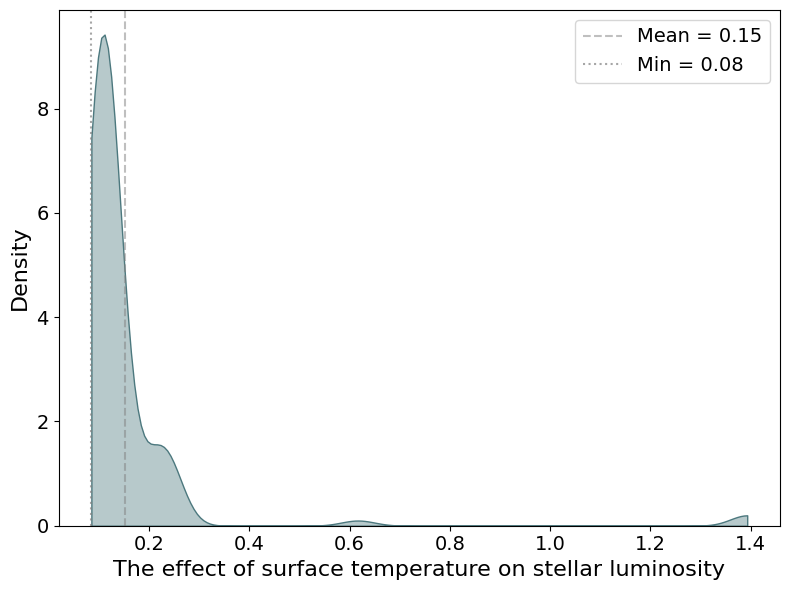

GenTE (test): n = 120, negative = 0 (0.0%)
  min = 0.08483, median = 0.1073, max = 1.393
0.084828034


In [ ]:
# Set style for better PDF output
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
# Increase only axis-related font sizes
plt.rcParams['axes.labelsize'] = 16  # Increased axis label size
plt.rcParams['xtick.labelsize'] = 14  # Increased tick label size
plt.rcParams['ytick.labelsize'] = 14  # Increased tick label size
plt.rcParams['legend.fontsize'] = 14  # Increased legend size

# Calculate mean of treatment effects
mean_effect = np.mean(tau_gen_test)
min_effect = np.min(tau_gen_test)



# Create density plot
plt.figure(figsize=(8, 6))
sns.kdeplot(data=tau_gen_test, color='#4C787E', fill=True, alpha=0.4,
            cut=0, bw_adjust=0.5, label='')

# Format y-axis to use scientific notation
plt.gca().yaxis.set_major_formatter(plt.ScalarFormatter(useMathText=True))
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))


plt.xlabel('The effect of surface temperature on stellar luminosity')
plt.ylabel('Density')
plt.title('')
plt.axvline(x=mean_effect, color='gray', linestyle='--', alpha=0.5, label=f'Mean = {mean_effect:.2f}')
plt.axvline(x=min_effect, color='gray', linestyle=':', alpha=0.7,
            label=f'Min = {min_effect:.2f}')
plt.legend()
plt.tight_layout()

# Save plots
plt.savefig(os.path.join(results_dir, 'treatment_effects_density_log.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(results_dir, 'treatment_effects_density_log.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()



def print_negative_share(theta, name='theta_hat'):
    theta = np.asarray(theta, float).ravel()
    neg = theta < -0.1
    print(f"{name}: n = {theta.size}, negative = {neg.sum()} "
          f"({100.0 * neg.mean():.1f}%)")
    print(f"  min = {theta.min():.4g}, median = {np.median(theta):.4g}, "
          f"max = {theta.max():.4g}")


print_negative_share(tau_gen_test, 'GenTE (test)')


print(min(tau_gen_test))

GRF (test): n = 120, negative = 120 (100.0%)
  min = -0.7826, median = -0.7764, max = -0.4758


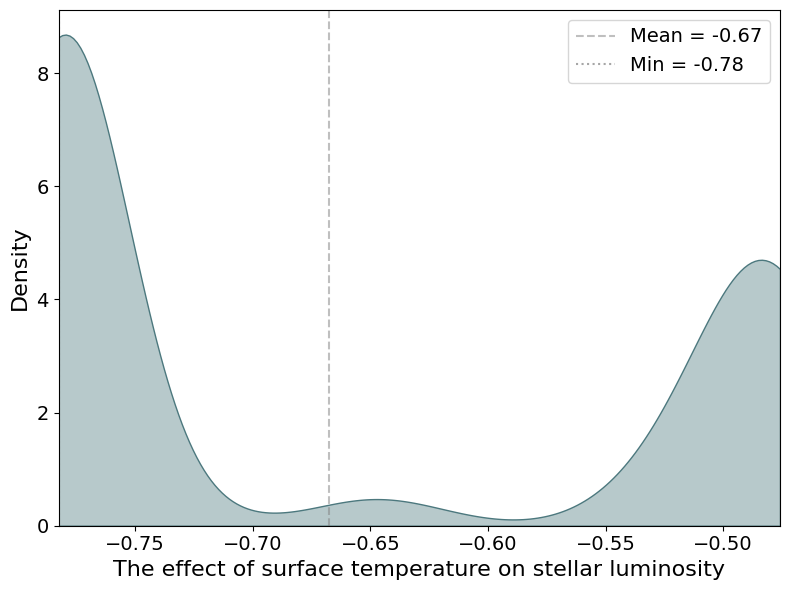

In [52]:
## Such a plot for GRF
# Set style for better PDF output
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14

print_negative_share(tau_grf_test, 'GRF (test)')

mean_effect_grf = np.mean(tau_grf_test)
min_effect_grf  = np.min(tau_grf_test)
max_effect_grf  = np.max(tau_grf_test)

plt.figure(figsize=(8, 6))
sns.kdeplot(data=tau_grf_test,
            color='#4C787E',
            fill=True,
            alpha=0.4,
            cut=0,
            bw_adjust=0.5,
            label='')

# scientific notation on the y-axis as a power of ten, not e-notation
plt.gca().yaxis.set_major_formatter(plt.ScalarFormatter(useMathText=True))
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.xlim(min_effect_grf, max_effect_grf)

plt.xlabel('The effect of surface temperature on stellar luminosity')
plt.ylabel('Density')
plt.title('')
plt.axvline(x=mean_effect_grf, color='gray', linestyle='--', alpha=0.5,
            label=f'Mean = {mean_effect_grf:.2f}')
plt.axvline(x=min_effect_grf, color='gray', linestyle=':', alpha=0.7,
            label=f'Min = {min_effect_grf:.2f}')
plt.legend()
plt.tight_layout()

plt.savefig(os.path.join(results_dir, 'treatment_effects_density_grf_log.pdf'),
            dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(results_dir, 'treatment_effects_density_grf_log.png'),
            dpi=300, bbox_inches='tight')
plt.show()
plt.close()